In [1]:
from scipy.stats import beta
import numpy as np

In [2]:
x = np.linspace(0, 1, 100)

In [3]:
from matplotlib import pyplot as plt

0.0 1.0 (8.0, 4.0)


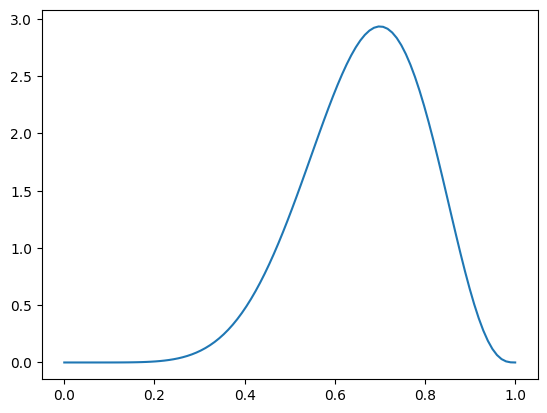

In [4]:
from scipy.stats import rv_continuous

def my_beta(mode: float, concentration: float) -> rv_continuous:
    """Generate a beta distribution with a specified mode and concentration.
    
    For a concave beta distribution, i.e. α > 1 and β > 1, the mode and concentration are given by:
    mode = (α - 1) / (α + β - 2)
    c = α + β - 2

    Solving for α and β gives:
    α = mode * c + 1
    β = (1 - mode) * c + 1

    See: https://en.wikipedia.org/wiki/Beta_distribution#Mode_and_concentration
    """
    if not (0 < mode < 1):
        raise ValueError("Mode must be between 0 and 1")
    if concentration <= 0:
        raise ValueError("Concentration must be greater than 0")
    
    alpha = mode * concentration + 1
    beta_param = (1 - mode) * concentration + 1
    return beta(alpha, beta_param)

dist = my_beta(mode=0.7, concentration=10)
print(dist.a, dist.b, dist.args)
plt.plot(x, dist.pdf(x))
plt.show()

In [5]:
from typing import Callable, Sequence, Sequence


def my_beta_scaled(
    mode: float, 
    concentration: float, 
    y_max: float = 1.0,
    y_left: float = 0.0,
    y_right: float = 0.0,
) -> Callable[[float], float]:
    """Generate a scaled beta distribution.
    
    Args:
        mode: The mode of the beta distribution (between 0 and 1).
        concentration: The concentration parameter of the beta distribution (greater than 0).
        y_left: The minimum value of the scaled PDF.
        y_right: The maximum value of the scaled PDF.
        y_max: The maximum value of the scaled PDF (used for scaling).
    
    Returns:
        A function that takes a value x (between 0 and 1) and returns the scaled PDF value.
    """
    unscaled_dist = my_beta(mode, concentration)

    # Calculate the maximum value of the unscaled PDF
    unscaled_max = unscaled_dist.pdf(mode)

    # Calculate scaling factors for the left and right sides of the distribution
    scale_factor_left = (y_max - y_left) / unscaled_max
    scale_factor_right = (y_max - y_right) / unscaled_max

    # Shift and scale the PDF to fit within the specified y_left and y_right bounds
    def scaled_pdf_scalar(x: float) -> float:
        if x < mode:
            return y_left + scale_factor_left * unscaled_dist.pdf(x)
        else:
            return y_right + scale_factor_right * unscaled_dist.pdf(x)
    
    # Vectorize the scaled PDF function to handle array inputs
    def scaled_pdf_vectorized(x: Sequence[float]) -> np.ndarray:
        return np.array([scaled_pdf_scalar(xi) for xi in x])
    
    def scaled_pdf(x: float | Sequence[float]) -> float | np.ndarray:
        if isinstance(x, (float, int)):
            return scaled_pdf_scalar(x)
        else:
            return scaled_pdf_vectorized(x)

    return scaled_pdf

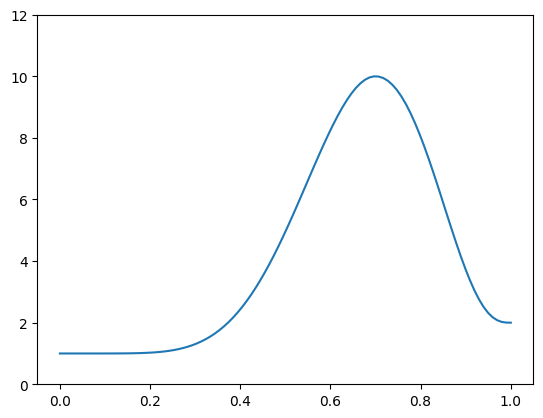

In [6]:
my_pdf = my_beta_scaled(mode=0.7, concentration=10, y_max=10.0, y_left=1.0, y_right=2.0)
plt.plot(x, my_pdf(x))
plt.ylim(0, 12)
plt.show()

In [7]:
from virus_sim_dashboard.components.stepper.step2 import process_stay_data
import json

main_store_data = json.load(open("private/main_store_data.json"))
stay_data = process_stay_data(main_store_data, "Admission", "FirstPosCollected")
stay_data

,Age,Admission,Discharge,ICUAdmission,...,FirstPosCollected,Acquisition,Summary,Start
0,22,2016-08-03 16:50:02,2016-08-04 12:46:27.840,NaT,...,2016-08-03 22:54:09.408,Community-Onset Community-Associated,Discharged,2016-08-03 16:50:02.000
1,84,2016-08-07 05:24:18,2016-08-10 17:19:21.600,NaT,...,2016-08-08 13:06:44.352,Community-Onset Community-Associated,Discharged,2016-08-07 05:24:18.000
2,48,2016-08-31 00:22:02,2016-09-01 16:59:48.096,NaT,...,2016-08-31 15:43:44.128,Community-Onset Community-Associated,Discharged,2016-08-31 00:22:02.000
3,22,2016-11-19 18:18:43,2016-11-21 18:39:04.704,NaT,...,2016-11-20 16:32:46.080,Community-Onset Community-Associated,Discharged,2016-11-19 18:18:43.000
4,50,2016-11-24 14:32:56,2016-11-25 18:00:22.272,NaT,...,2016-11-25 17:07:56.544,Community-Onset Community-Associated,Discharged,2016-11-24 14:32:56.000
...,...,...,...,...,...,...,...,...,...
4694,78,2025-05-07 21:44:00,2025-05-17 20:02:24.896,NaT,...,2025-05-15 23:59:07.776,Hospital-Onset Healthcare-Associated,Discharged,2025-05-15 23:59:07.776
4695,91,2025-05-15 15:32:00,2025-05-27 10:43:37.088,NaT,...,2025-05-16 12:00:01.536,Community-Onset Community-Associated,Discharged,2025-05-15 15:32:00.000
4696,84,2025-05-17 10:55:00,2025-05-19 15:06:43.072,NaT,...,2025-05-17 12:36:46.208,Community-Onset Community-Associated,Discharged,2025-05-17 10:55:00.000
4697,7,2025-05-19 14:15:00,2025-05-19 18:12:24.192,NaT,...,2025-05-19 14:14:17.344,Community-Onset Community-Associated,Discharged,2025-05-19 14:15:00.000


In [8]:
tmp = stay_data.loc[(stay_data["Start"] >= "2024-09-01") & (stay_data["Start"] <= "2025-05-31")]
tmp = tmp.set_index("Start").resample("D").size()

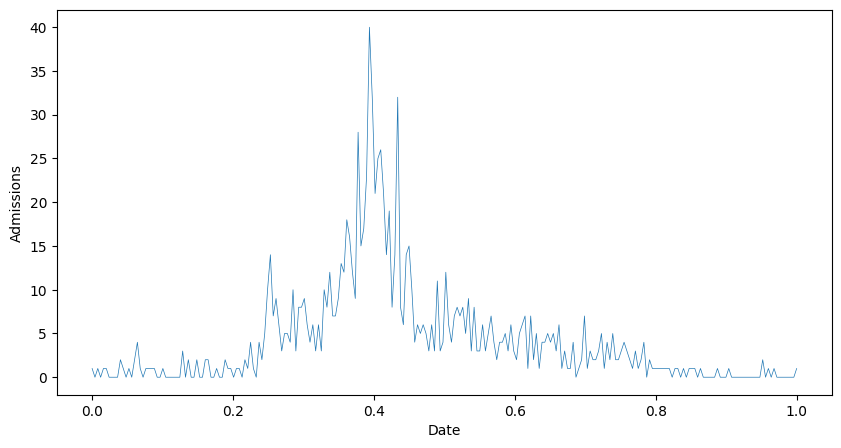

In [9]:
%matplotlib inline

import pandas as pd

df = pd.DataFrame(
    {
        "ScaledDate": np.linspace(0, 1, len(tmp)),
        "Admissions": tmp.values,
    },
    index=tmp.index
)
df.plot(x="ScaledDate", y="Admissions", lw=0.5, figsize=(10, 5), legend=False)
plt.xlabel("Date")
plt.ylabel("Admissions")
plt.show()

In [10]:
df

,ScaledDate,Admissions
Start,,
2024-09-20,0,1
2024-09-21,0.00401606,0
2024-09-22,0.00803213,1
2024-09-23,0.0120482,0
2024-09-24,0.0160643,1
...,...,...
2025-05-23,0.983936,0
2025-05-24,0.987952,0
2025-05-25,0.991968,0


In [11]:
from scipy.optimize import curve_fit

def fit_beta(
    dailies: pd.Series,
    zero_left: bool = True,
    zero_right: bool = True
):
    """Fit a beta distribution to the given daily data.
    
    Args:
        dailies: A pandas Series with daily counts, indexed by date.
    
    Returns:
        The parameters of the fitted beta distribution (compatible with `my_beta_scaled`).
    """

    # Scale the dates to the interval [0,1]
    df = pd.DataFrame(
        {
            "ScaledDate": np.linspace(0, 1, len(dailies)),
            "Admissions": dailies.values,
        },
        index=dailies.index
    )

    # For the function names, "z" stands for zero and "f" stands for free (non-zero)
    fit_zz = lambda mode, conc, y_max: my_beta_scaled(mode, conc, y_max=y_max, y_left=0.0, y_right=0.0)
    fit_fz = lambda mode, conc, y_max, left: my_beta_scaled(mode, conc, y_max=y_max, y_left=left, y_right=0.0)
    fit_zf = lambda mode, conc, y_max, right: my_beta_scaled(mode, conc, y_max=y_max, y_left=0.0, y_right=right)
    fit_ff = lambda mode, conc, y_max, left, right: my_beta_scaled(mode, conc, y_max=y_max, y_left=left, y_right=right)

    # Initial estimate for mode: scaled date corresponding to the maximum daily count
    initial_mode = df.loc[df["Admissions"].idxmax(), "ScaledDate"]
    # Initial estimate for concentration
    initial_concentration = 10.0
    # Initial estimate for y_max: maximum daily count
    initial_y_max = df["Admissions"].max()
    # Initial estimates for y_left and y_right: first and last daily counts
    initial_y_left = df["Admissions"].iloc[0] if not zero_left else 0.0
    initial_y_right = df["Admissions"].iloc[-1] if not zero_right else 0.0

    initials = (
        (initial_mode, initial_concentration, initial_y_max) if zero_left and zero_right
        else (initial_mode, initial_concentration, initial_y_max, initial_y_left) if not zero_left and zero_right
        else (initial_mode, initial_concentration, initial_y_max, initial_y_right) if zero_left and not zero_right
        else (initial_mode, initial_concentration, initial_y_max, initial_y_left, initial_y_right)
    )

    lower_bounds = (
        (0.0, 0.0, 0.0) if zero_left and zero_right
        else (0.0, 0.0, 0.0, 0.0) if not zero_left and zero_right
        else (0.0, 0.0, 0.0, 0.0) if zero_left and not zero_right
        else (0.0, 0.0, 0.0, 0.0, 0.0)
    )

    upper_bounds = (
        (1.0, np.inf, np.inf) if zero_left and zero_right
        else (1.0, np.inf, np.inf, df["Admissions"].max()) if not zero_left and zero_right
        else (1.0, np.inf, np.inf, df["Admissions"].max()) if zero_left and not zero_right
        else (1.0, np.inf, np.inf, df["Admissions"].max(), df["Admissions"].max())
    )

    fit_func = (
        fit_zz if zero_left and zero_right
        else fit_fz if not zero_left and zero_right
        else fit_zf if zero_left and not zero_right
        else fit_ff
    )

    params, _ = curve_fit(
        lambda x, *params: fit_func(*params)(x),
        df["ScaledDate"],
        df["Admissions"],
        p0=initials,
        bounds=(lower_bounds, upper_bounds)
    )

    params_dict = {
        "start_date": df.index[0],
        "end_date": df.index[-1],
        "mode": params[0],
        "concentration": params[1],
        "y_max": params[2],
        "y_left": params[3] if not zero_left else 0.0,
        "y_right": params[4] if not zero_right else 0.0,
    }

    return params_dict

In [12]:
my_fit = fit_beta(df["Admissions"], zero_left=False, zero_right=True)
my_fit_fn = my_beta_scaled(
    mode=my_fit["mode"],
    concentration=my_fit["concentration"],
    y_max=my_fit["y_max"],
    y_left=my_fit["y_left"],
    y_right=my_fit["y_right"]
)
my_fit

{'start_date': Timestamp('2024-09-20 00:00:00'),
 'end_date': Timestamp('2025-05-27 00:00:00'),
 'mode': np.float64(0.3997808450097971),
 'concentration': np.float64(90.4582763903765),
 'y_max': np.float64(20.708796673131072),
 'y_left': np.float64(1.664967940890714),
 'y_right': 0.0}

/tmp/ipykernel_1137447/167685187.py:4: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(df.index, df["ScaledDate"].map(my_fit_fn))


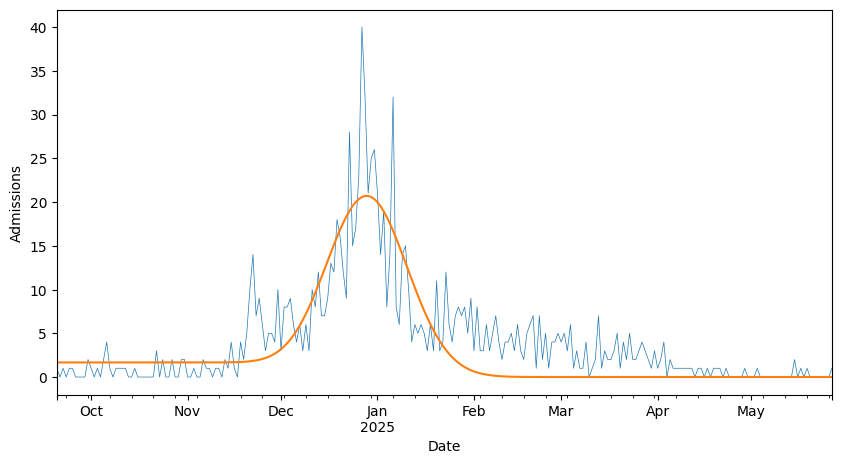

In [13]:
df.plot(y="Admissions", lw=0.5, figsize=(10, 5), legend=False)
plt.xlabel("Date")
plt.ylabel("Admissions")
plt.plot(df.index, df["ScaledDate"].map(my_fit_fn))